# Batch Normalization

To further improve the model, we'd like to normalize/standardize the data. With our pixel values following the srgb range of 0-255, we would like to avoid giving unfair representation to say the higher values in this scale rather than the values closer to zero. 
In a related example, imagine two feature that we'll pass in as inputs to a network, the first being yearly income, and the second being age.

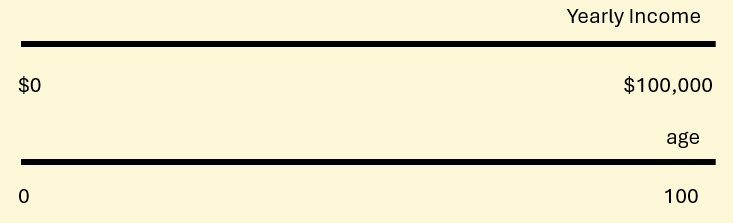  

If we appllied these filters without normalizing their range then we'd end up having the yearly income feature become disproportionately more **important** to the model then the age filter would ever become. To combat this, we normalize activation such that each feature has mean 0 and variance 1 during training. 
If we had a layer outptu $X$ with shape (batch size, height, width, channels) the steps are:
1. Compute mean and variance across the batch
  For channel $c$:   
$$
\mu _c = \frac{1}{S \cdot H \cdot W} \displaystyle \sum_{i=1}^{S} \sum_{h = 1}^{H} \sum_{w = 1}^{W} X_{i,h,w,c}  
$$
$$
\sigma ^2 _{c} = \frac{1}{S \cdot H \cdot W} \displaystyle \sum_{i=1}^{S} \sum_{h = 1}^{H} \sum_{w = 1}^{W} (X_{i,h,w,c} - \mu _c)^2 
$$
  where
  * S: batch size
  * H, W: spatial dimensions
  * c: channel index
2. Normalize activations

$$
\hat X_{i,h,w,c} = \frac {X_{i,h,w,c} - \mu _c}{\sqrt {\sigma ^2 _c + \epsilon}}
$$
  where:
  * $\epsilon$ is a small number (1e -5) to avoid division by zero. 

3. Scale and shift (optional learnable paramters): 
$$
Y_{i,h,w,c} = \gamma _c \hat X_{i, h, w, c} + \beta _c
$$
  where:
  * $ \gamma _c \text{ and } \beta _c $ are trainable paramters per channel. We can use these to undo normalization if necessary

When we initalize the layer Batch_Norm in our model, we would also like to keep some "memory" or **momentum** of the previous averages of the mean and variance. 
We'll start with the __init__ method below
```python
#ahh
def __init__ (self, epsilon = 1e-5, momentum = 0.9):
  self.epsilon = epsilon
  self.momentum = momentum
  self.beta = None
  self.gamma = None
  self.running_mean = None
  self.running_var = None
```
As for the foward pass, all we need to do is compute the three equations above. 
Lets tackle $\mu _c$ and $\sigma _c ^2$ first. 
If we look closer at the equation, we are taking the mean over the sample, height, and width dimensions, then we divide that by (N * H * W). All in all, this step would look like 

```python
#X.shape (S, H, W, C)
mu = X.mean(axis = (0, 1, 2)) / (N * H * W)
#now divide by N * H * W
```
After performing this step, we'd recieve a vector of length C, meaning one mean per channel. 

Next, we need to calculate the variance where we'll use the same idea
```python
#X.shape (S, H, W, C)
var = X.var(axis = (0, 1, 2)) / (N * H * W)
```

We now need to normalize the activations, where at each element we'd standardize it using the same equation from above 

$$
\hat X_{i,h,w,c} = \frac {X_{i,h,w,c} - \mu _c}{\sqrt {\sigma ^2 _c + \epsilon}}
$$
  
Luckily for us, we can write this in one line

```python
normalized = (inputs - mu) / cp.sqrt(var + self.epsilon)
```

$$
Y_{i,h,w,c} = \gamma _c \hat X_{i, h, w, c} + \beta _c
$$

Our last step is to scale and shift which will become our output, since this is a simple operation the code will look as such:

```python
self.output = self.gamma * self.normalized + self.beta
```

We have now performed the foward pass of batch normalization. However, we still need to utilize the momentum attribute to keep some momentum from previous iterations. 

```python
self.running_mean = self.momentum * self.running_mean + (1 - self.momentum) * cp.squeeze(batch_mean)
self.running_var = self.momentum * self.running_var + (1 - self.momentum) * cp.squeeze(batch_var)
```

Here, we apply the momentum of the previous mean and variances and multiply them by the momentum, then we add the current mean and variance and multiply that by the same momentum. With a few if statements to instantiate the running statistics and the beta and gamma, we have the full foward pass below

In [ ]:
import numpy as np
class Batch_Norm:
    def __init__ (self, epsilon = 1e-5, momentum = 0.9):
        self.epsilon = epsilon
        self.momentum = momentum
        self.gamma = None
        self.beta = None
        self.running_mean = None
        self.running_var = None
    
    def forward(self, inputs, training):
        self.inputs = inputs
        S = inputs.shape[0]
        C = inputs.shape[-1]

        if self.gamma is None: 
            self.gamma = np.ones(C, dtype=np.float32)
        if self.beta is None:
            self.beta = np.ones(C, dtype = np.float32)
        if self.running_mean is None:
            self.running_mean = np.zeros(C, dtype = np.float32)
            self.running_var = np.ones(C, dtype = np.float32)
        
        if inputs.ndim == 4: #if cnn
            axis = (0, 1, 2) 
        else: #dense
            axis = 0
        
        if training: 
            self.batch_mean = np.mean(inputs, axis = axis, keepdims = True)
            self.batch_var = np.var(inputs, axis = axis, keepdims = True)

            self.normalized = (inputs - self.batch_mean) / np.sqrt(self.batch_var + self.epsilon)
            self.output = self.gamma * self.normalized + self.beta

            #now update the running statistics
            self.running_mean = self.momentum * self.running_mean + (1 - self.momentum)
            self.running_var = self.momentum * self.running_var + (1 - self.momentum)
        
        else:
            self.normalized = (inputs - self.running_mean) / np.sqrt(self.running_var + self.epsilon)
            self.output = self.gamma * self.normalized + self.beta

        return self.output 

# Batch Normalization Backpropagation 

For this section, I will be following notes found from this video https://www.youtube.com/watch?v=tUs8K07h2T4&t=239s

He uses a simple perceptron with two inputs $x_1 \text{and} x_2$ but the math still applies for any amount of inputs i.  
  
  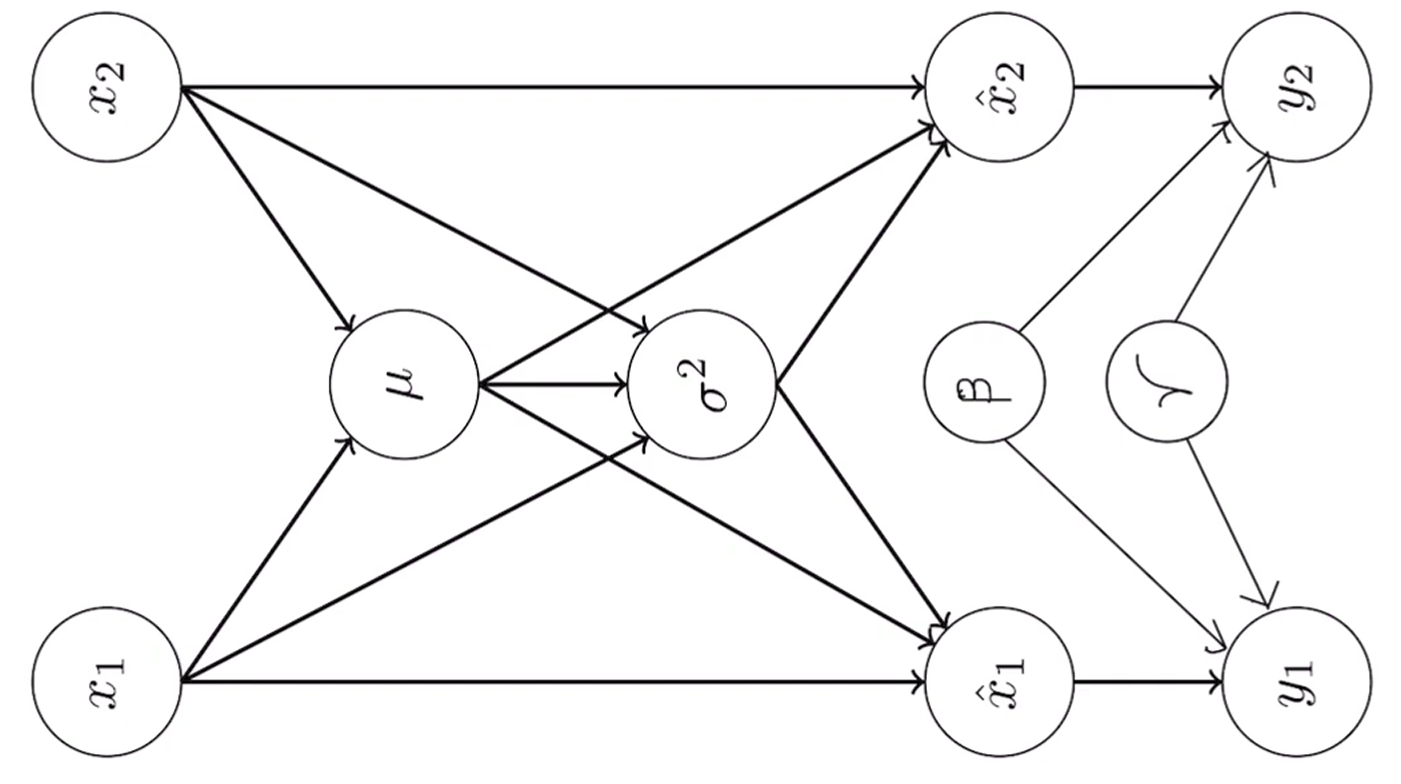

First, we'll pass in our dvalues, which is again of shape (N, H, W, C). batch normalization still happens per channel C 
$$
\frac{\partial L}{\partial y_i}
$$
the dvalues are going to be a vector or 2d vector of (y_i, channel) 
where in this case i denotes the batch. Using the graph we need to traverse back or to the left. We would like to calculate the partials of whatever affected our inputs. 
$$
\frac{\partial L}{\partial \beta}
$$

$$
\frac{\partial L}{\partial \gamma}
$$

$$
\frac{\partial L}{\partial x_i }
$$

$$
\frac{\partial L}{\partial \mu _B}
$$

$$
\frac{\partial L}{\partial \sigma ^2 _B}
$$

$$
\frac{\partial L}{\partial  \hat x_i}
$$

1. **Loss w.r.t beta parameter**
We'll start with the partial w.r.t. $\beta$, where we'll use the simple graphic as a guideline.  

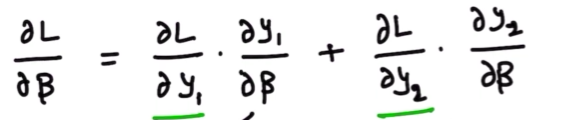

Here, we'll calculate each of the calculations of output y_i w.r.t beta, and taking the weighted sum. The equation of y_i is 

$$
\frac{\partial y_i}{\partial \beta} = \frac{\partial}{\partial \beta} \gamma * \hat x_i + \beta

$$

because we are taking the partial w.r.t beta the first term cancels out, meaning for every i
$$
\frac{\partial y_i}{\partial \beta} = 1
$$
Since we need to take the weighted sum then our partial becomes the sum of dvalues or in other words. 

$$
\frac{\partial y_i}{\partial \beta} = \sum_{i = 1} ^n \frac{\partial L}{\partial y_i}
$$

2. **Loss w.r.t gamma parameter.**  

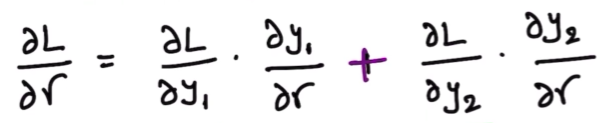

We'd now calculate the partials of each of the outputs w.r.t our gamma paramter $\gamma$

$$
\frac{\partial y_i}{\partial \gamma} = \frac{\partial}{\partial \gamma} (\gamma \cdot \hat x_1 + \beta)
$$

Of course, in this case taking the partial means that our beta term tends to zero while our gamma term will result in the output of xhat_i. 

$$
\frac{\partial y_i}{\partial \gamma} = \hat x_i
$$

Again, we need to take the sum of each of these partial operations, so our final formula will become

$$
\frac{\partial y_i}{\partial \gamma} = \sum_{i = 1}^n \frac{\partial L}{\partial y_i} \cdot \hat x_i
$$

3. **Loss w.r.t. xhat paramter.**

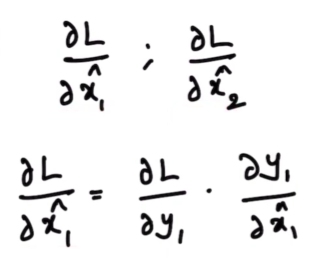

In this case, we already know our yhat derivative we just need to calculate the partial of y_i w.r.t xhat_i. In this case, 

$$
\frac{\partial L}{\partial \hat x_i } = \frac{\partial L}{\partial y_i} \cdot \frac{\partial}{\partial \hat x_i} (\gamma \cdot \hat x_1 + \beta)
$$

When we apply our deriviative, notice that we our going to cancel out gamma since gamma tends to zero, and since we are taking the partial w.r.t xhat_i then all that we'd be left with is $\gamma$ * 1 along with our dvalues. 

$$
\frac{\partial L}{\partial x_i } = \frac{\partial L}{\partial y_i} \cdot \gamma
$$

4. **Loss w.r.t variance**  

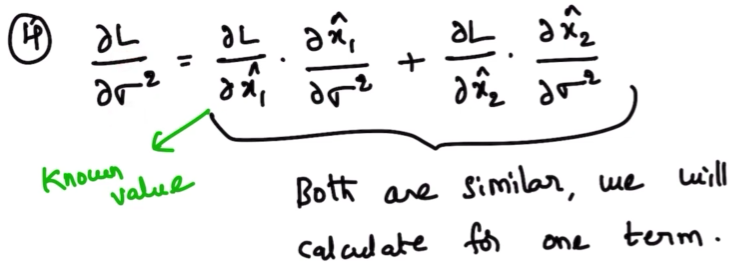
$$
\frac{\partial L}{\partial \sigma ^2}
$$

For us, we will be performing a single calculation of the variance, where at each point we'd take the derivaitve of the variance, the calculations behind this are a little complicated so I will print the result below instead. 

$$
\frac{\partial L}{\partial \sigma ^2} = \sum _{i=1}^n \frac{\partial L}{\partial \hat x_i } \cdot {(x_i - \mu)}\cdot \frac {-1}{2} (\sigma ^2 + \epsilon)^{-3/2}
$$

5. **Loss w.r.t mean**

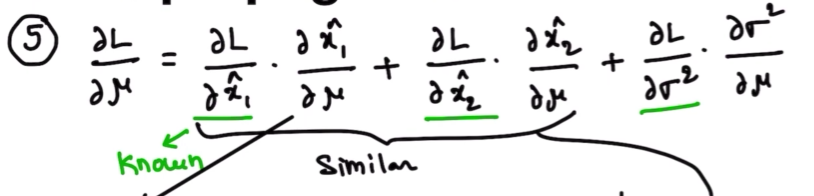

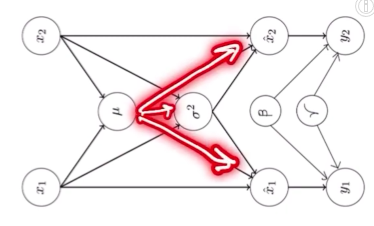

He explains that there are 3 terms in the formula as the mean is used to calculate the variance as well as every xhat that comes after as well. The green partials that are underlined denote or partials of the xhats with the last partial being the partial of the standard deviation which we have found in step 4. Now, we need to find the subsequent partials for each of the two types of cases. 

I will be skipping most of the steps but for the first case (the ones that are the partial of xhat_i w.r.t mean) will be:

$$
\sum _{i = 1} ^ n \frac{\partial L}{\partial x_i } \cdot \frac{-1}{\sqrt{\sigma ^2 + \epsilon}}
$$
The second part of the equation which is our partial of the standard deviation w.r.t the mean is 

$$
\frac{1}{n} \cdot \sum_{i=1}^n -2 \cdot (x_i - \mu)
$$

Therefore, our final equation to find the loss w.r.t mu is 

$$
\frac{\partial L}{\partial \mu} = \sum _{i = 1} ^ n \frac{\partial L}{\partial x_i } \cdot \frac{-1}{\sqrt{\sigma ^2 + \epsilon}} + \frac{\partial L}{\partial \sigma ^2} \cdot \frac{1}{n} \cdot \sum_{i=1}^n -2 \cdot (x_i - \mu)
$$

6. **Loss w.r.t inputs dinputs **

With the graphic, each input will influnece a total of 3 things, the mean, the variance, and the xhat input that is normalized. So again we'll have to deal with three cases which looks like. 
 
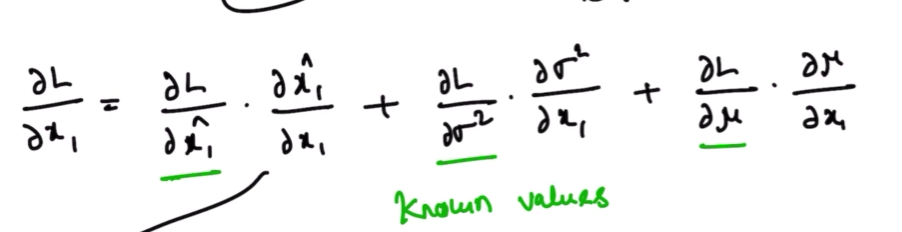

With the picture, each of the green underlines represent values that we already have, so all we need to do is find the corrsponding derivatives for each of the three cases listed.  

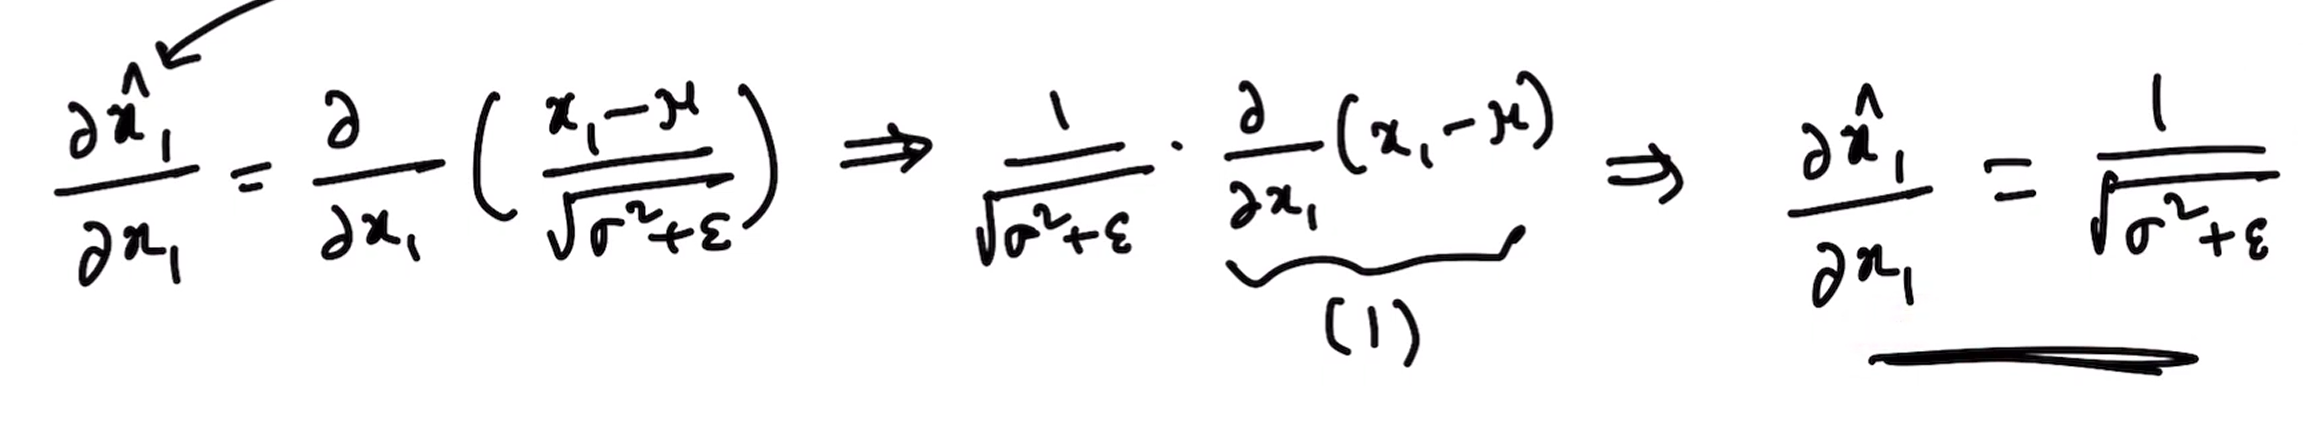

We observe the process of getting the partial of xhat w.r.t its input x_i, with this information he grabs the partial of x_i as well as the formula used to get x_i, then he applies the chain rule and we end up with the equation on the right

$$
\frac{\partial \hat x_1}{\partial x_1} = \frac{1}{\sqrt{\sigma ^2 + \epsilon}}
$$

for the second case, he again expands the sigma formula and takes the partial, after doing some algebraic steps we arrive at

$$
\frac{\partial \sigma^2}{\partial x_i} = \frac {2 (x_i - \mu)}{n}
$$

Finally, the third case we need to find the mean w.r.t. x, 
$$
\frac{\partial \mu}{\partial x_i} = \frac{\partial}{\partial x_i} (\frac{x_1 + ... + x_n}{N})
$$

All in all, the final formula (the one we actually care about) will then become 
$$
\frac{\partial L}{\partial x_i} = \frac{\partial L}{\partial \hat x_i } \cdot \frac{1}{\sqrt{\sigma ^2 + \epsilon}} + \frac{\partial L}{\partial \sigma ^2} \cdot \frac{2(x_i - \mu)}{m}
+ \frac{\partial L}{\partial \mu} \cdot \frac{1}{m}
$$

# Implementation of backpropagation 

Now that we have the final formula, lets start by coding in $\frac{\partial L}{\partial \hat x_i }$. Remember, this partial is based on the formula 

$$
\frac{\partial L}{\partial x_i } = \frac{\partial L}{\partial y_i} \cdot \gamma
$$

In code, this would look like 

```python
dhatx = dvalues * self.gamma # same shape as (N, H, W, C)
```

Now, we'd like to find out what $\frac{\partial L}{\partial \sigma ^2}$ is. This formula was based on 

$$
\frac{\partial L}{\partial \sigma ^2} = \sum _{i=1}^n \frac{\partial L}{\partial \hat x_i } \cdot {(x_i - \mu)}\cdot \frac {-1}{2} (\sigma ^2 + \epsilon)^{-3/2}
$$

Since we are taking a sum over everything, we know to start with np.sum(). Inside the paramter, we'd like to take the sum over our dhatx times the sample multiplied by the mean. 

We can so far say that part of our equation looks like
```python
dvar_partial_solution = np.sum(dhatx * (self.inputs - self.batch_mean) * (-0.5))
```

Now, lets approach the last part $(\sigma ^2 + \epsilon)^{-3/2}$, here since we have already stored these values in the foward pass we can add it to the equation as such

```python
dvar = np.sum(dhatx * (self.inputs - self.batch_mean) * (-0.5) * np.power(self.batch_var + epsilon, -1.5, axis = (0, 1, 2), keepdims = True))
```

Next, lets calculate $\frac{\partial L}{\partial \mu}$ which we'll later multiply by $\frac{1}{n}$. This partial is represented with the formula 
$$
\frac{\partial L}{\partial \mu} = (\sum _{i = 1} ^ m \frac{\partial L}{\partial \hat x_i } \cdot \frac{-1}{\sqrt{\sigma ^2 + \epsilon}}) + \frac{\partial L}{\partial \sigma ^2} \cdot \frac{\sum_{i=1}^n -2 \cdot (x_i - \mu)}{m}  
$$
* m consists of the sum of N * H * W since we have the ability to use this for a CNN

```python
N = np.prod([self.inputs.shape[ax] for ax in axes])

dmu = np.sum(dhatx * (-1.0 / np.sqrt(self.batch_var + self.epsilon)), axis = axes, keepdims = True) + dvar * np.sum(-2.0 * (self.inputs - self.batch_mean), axis = axes, keepdims = True) / N
```
We can now properly approach the dinputs formula again. 

$$
\frac{\partial L}{\partial x_i} = \frac{\partial L}{\partial \hat x_i } \cdot \frac{1}{\sqrt{\sigma ^2 + \epsilon}} + \frac{\partial L}{\partial \sigma ^2} \cdot \frac{2(x_i - \mu)}{m}
+ \frac{\partial L}{\partial \mu} \cdot \frac{1}{m}
$$

All in all, the code for dinputs would look like 

```python
inv_sqrt = 1.0 / np.sqrt(self.batch_var + self.epsilon) #shape (1, 1, 1, C)
self.dinputs = (dhatx * inv_sqrt + dvar * 2.0 * (self.inputs - self.batch_mean / N) + dmu / N) 
```

We have now gone through all the steps needed to perform the backwards pass of our model. The full code will be below.  

In [ ]:
import numpy as np
class Batch_Norm:
    def __init__ (self, epsilon = 1e-5, momentum = 0.9):
        self.epsilon = epsilon
        self.momentum = momentum
        self.gamma = None
        self.beta = None
        self.running_mean = None
        self.running_var = None
    
    def forward(self, inputs, training):
        self.inputs = inputs
        S = inputs.shape[0]
        C = inputs.shape[-1]

        if self.gamma is None: 
            self.gamma = np.ones(C, dtype=np.float32)
        if self.beta is None:
            self.beta = np.ones(C, dtype = np.float32)
        if self.running_mean is None:
            self.running_mean = np.zeros(C, dtype = np.float32)
            self.running_var = np.ones(C, dtype = np.float32)
        
        if inputs.ndim == 4: #if cnn
            axis = (0, 1, 2) 
        else: #dense
            axis = 0
        
        if training: 
            self.batch_mean = np.mean(inputs, axis = axis, keepdims = True)
            self.batch_var = np.var(inputs, axis = axis, keepdims = True)

            self.normalized = (inputs - self.batch_mean) / np.sqrt(self.batch_var + self.epsilon)
            self.output = self.gamma * self.normalized + self.beta

            #now update the running statistics
            self.running_mean = self.momentum * self.running_mean + (1 - self.momentum)
            self.running_var = self.momentum * self.running_var + (1 - self.momentum)
        
        else:
            self.normalized = (inputs - self.running_mean) / np.sqrt(self.running_var + self.epsilon)
            self.output = self.gamma * self.normalized + self.beta

        return self.output 
    
    def backward(self, dvalues):
        axes = (0, 1, 2) if dvalues.ndim == 4 else (0,)
        N_total = np.prod([self.inputs.shape[ax] for ax in axes])

        dhatx = dvalues * self.gamma # same shape as (N, H, W, C)

        dvar = np.sum(dhatx * (self.inputs - self.batch_mean)
                    * (-0.5)
                    * np.power(self.batch_var + self.epsilon, -1.5),
                    axis = axes,
                    keepdims = True)

        dmu = np.sum(dhatx * (-1.0 / np.sqrt(self.batch_var + self.epsilon)),
                    axis = axes, keepdims = True) \
                    + dvar * np.sum(-2.0 * (self.inputs - self.batch_mean),
                    axis = axes, keepdims = True) / N_total

        inv_sqrt = 1.0 / np.sqrt(self.batch_var + self.epsilon) #shape (1, 1, 1, C)
        self.dinputs = (dhatx * inv_sqrt + dvar * 2.0 * (self.inputs - self.batch_mean / N_total) \
                        + dmu / N_total)
        
        
        self.dgamma = np.sum(dvalues * self.normalized, axis=axes, keepdims=True)
        self.dbeta = np.sum(dvalues, axis=axes, keepdims=True)

        return self.dinputs 